In [1]:
import pandas as pd
import numpy as np
import os
import network_utils

# Define the base path to the raw data
raw_dir = 'dataset/ogbn_arxiv/raw'
mapping_dir = 'dataset/ogbn_arxiv/mapping'

# 1. Load the Citation Edges (adjacency list)
# Format: source_node, target_node
edges = pd.read_csv(os.path.join(raw_dir, 'edge.csv.gz'), compression='gzip', header=None)
edges.columns = ['source', 'target']

# 2. Load the Node Features (128-dimensional embeddings)
# These are usually stored as a compressed CSV or NPY. OGB uses CSV.gz for raw.
node_feat = pd.read_csv(os.path.join(raw_dir, 'node-feat.csv.gz'), compression='gzip', header=None)

# 3. Load Node years
node_year = pd.read_csv(os.path.join(raw_dir, 'node_year.csv.gz'), compression='gzip', header=None)
node_year.columns = ['year']

# 4. Load Node to Paper ID mapping (Critical for linking to titleabs.tsv)
node_mapping = pd.read_csv(os.path.join(mapping_dir, 'nodeidx2paperid.csv.gz'), compression='gzip')

# 5. Load labels (subject categories)
label_mapping = pd.read_csv(os.path.join(raw_dir, 'node-label.csv.gz'), compression='gzip', header=None)

print(f"Loaded {len(node_feat)} nodes")
print(f"Loaded {len(edges)} citation links")
print(f"Columns in mapping: {node_mapping.columns.tolist()}")

Loaded 169343 nodes
Loaded 1166243 citation links
Columns in mapping: ['node idx', 'paper id']


In [2]:
# load mapping from label numbers to category names
label_category_mapping = pd.read_csv(os.path.join(mapping_dir, 'labelidx2arxivcategeory.csv.gz'), compression='gzip')

print(label_category_mapping.head())
print(f"Total categories: {len(label_category_mapping)}")

   label idx arxiv category
0          0    arxiv cs na
1          1    arxiv cs mm
2          2    arxiv cs lo
3          3    arxiv cs cy
4          4    arxiv cs cr
Total categories: 40


In [3]:
label_mapping.columns = ['label idx']

labels_with_node = label_mapping.reset_index().rename(columns={'index': 'node idx'})

labels_merged = labels_with_node.merge(label_category_mapping, on='label idx', how='left')

labels_merged = labels_merged.merge(node_mapping, on = "node idx")

print(labels_merged.head())


   node idx  label idx arxiv category   paper id
0         0          4    arxiv cs cr    9657784
1         1          5    arxiv cs dc   39886162
2         2         28    arxiv cs it  116214155
3         3          8    arxiv cs ni  121432379
4         4         27    arxiv cs ro  231147053


In [4]:
print(node_year)

        year
0       2013
1       2015
2       2014
3       2014
4       2014
...      ...
169338  2020
169339  2020
169340  2020
169341  2020
169342  2020

[169343 rows x 1 columns]


We see that (u, v) is an edge if u cites v

In [5]:
# Map source and target node indices to their publication years
source_years = node_year.loc[edges['source'], 'year'].values
target_years = node_year.loc[edges['target'], 'year'].values

# Calculate the fraction of edges matching each direction
source_cites_target = (source_years >= target_years).mean()
target_cites_source = (target_years > source_years).mean()

print(f"Fraction of edges where source_year >= target_year (u cites v): {source_cites_target:.4%}")
print(f"Fraction of edges where target_year >= source_year (v cites u): {target_cites_source:.4%}")


Fraction of edges where source_year >= target_year (u cites v): 98.2077%
Fraction of edges where target_year >= source_year (v cites u): 1.7923%


We include only papers from years 2000-2012

In [4]:
target_years = [year for year in range(2000, 2013)]
papers_in_range = node_year[node_year['year'].isin(target_years)]
print(papers_in_range.head(10))
node_indices = set(papers_in_range.index.tolist())

    year
7   2011
10  2012
13  2004
18  2009
21  2010
22  2008
26  2009
29  2011
33  2012
40  2008


In [5]:
filtered_edges = edges[edges["source"].isin(node_indices) & edges["target"].isin(node_indices)]
print(f"Total internal edges: {len(filtered_edges)}")
print(filtered_edges.head())

Total internal edges: 45697
    source  target
0   104447   13091
11   82077   19879
12   82077  147042
13   82077   35436
20   88685   11734


In [6]:
import networkx as nx

nodes = list(node_indices)
G = nx.DiGraph()

G.add_nodes_from(nodes)

# Convert each edge to a tuple of (int, int)
edges_to_add = [tuple(map(int, edge)) for edge in filtered_edges.values]
G.add_edges_from(edges_to_add)


In [7]:
edge_set = set(edges_to_add)

# Find edges (u, v) where (v, u) also exists in the list
reciprocal_edges = [edge for edge in edges_to_add if (edge[1], edge[0]) in edge_set]

print(f"Total edges: {len(edges_to_add)}")
print(f"Number of reciprocal edges found: {len(reciprocal_edges)}")

if reciprocal_edges:
    print("Example reciprocal edges (source, target):")
    for i in range(min(5, len(reciprocal_edges))):
        u, v = reciprocal_edges[i]
        print(f"Edge: ({u}, {v}) | Opposite: ({v}, {u})")

Total edges: 45697
Number of reciprocal edges found: 3156
Example reciprocal edges (source, target):
Edge: (148333, 7857) | Opposite: (7857, 148333)
Edge: (83333, 10551) | Opposite: (10551, 83333)
Edge: (76903, 9122) | Opposite: (9122, 76903)
Edge: (148337, 142396) | Opposite: (142396, 148337)
Edge: (25140, 29192) | Opposite: (29192, 25140)


There are many reciprocal edges, for example:
Year 2012 <-> Year 2003


In [8]:
# Check years of reciprocal edges
for i in range(min(10, len(reciprocal_edges))):
    u, v = reciprocal_edges[i]
    year_u = node_year.loc[u, 'year']
    year_v = node_year.loc[v, 'year']
    print(f"Edge ({u}, {v}): Year {year_u} <-> Year {year_v}")

Edge (148333, 7857): Year 2012 <-> Year 2003
Edge (83333, 10551): Year 2009 <-> Year 2009
Edge (76903, 9122): Year 2006 <-> Year 2007
Edge (148337, 142396): Year 2011 <-> Year 2009
Edge (25140, 29192): Year 2010 <-> Year 2011
Edge (15861, 99171): Year 2011 <-> Year 2010
Edge (152174, 123132): Year 2008 <-> Year 2008
Edge (96623, 137697): Year 2003 <-> Year 2003
Edge (115174, 2706): Year 2007 <-> Year 2007
Edge (115174, 135871): Year 2007 <-> Year 2007


Removing single nodes in weakly connected components (they are useless):

In [9]:
nodes_for_removal = []
for comp in nx.weakly_connected_components(G):
        if len(comp) == 1:
            for node in comp:
                nodes_for_removal.append(node)

G.remove_nodes_from(nodes_for_removal)

## Random Networks Generation and Comparison

First we describe our network with relevant general information


In [12]:
network_utils.describe_network_directed(G)

,Nodes,Edges,Average In/Out Degree,Weakly Connected Components,Average Clustering Coefficient,Largest Connected Component,Average Shortest Path
0,20515,45697,2.227492,965,0.135714,16874,10.162299


We generate three random networks:
- Watts-Strogatz
- Erdos-Renyi
- Barabasi-Albert

In [10]:
G_undir = G.to_undirected()
v = G_undir.number_of_nodes()
e = G_undir.number_of_edges()
erdos = nx.gnm_random_graph(v, e)
barabasi = nx.barabasi_albert_graph(v, round(e/v))
watts = nx.connected_watts_strogatz_graph(v, round(2*e/v), 0.1)


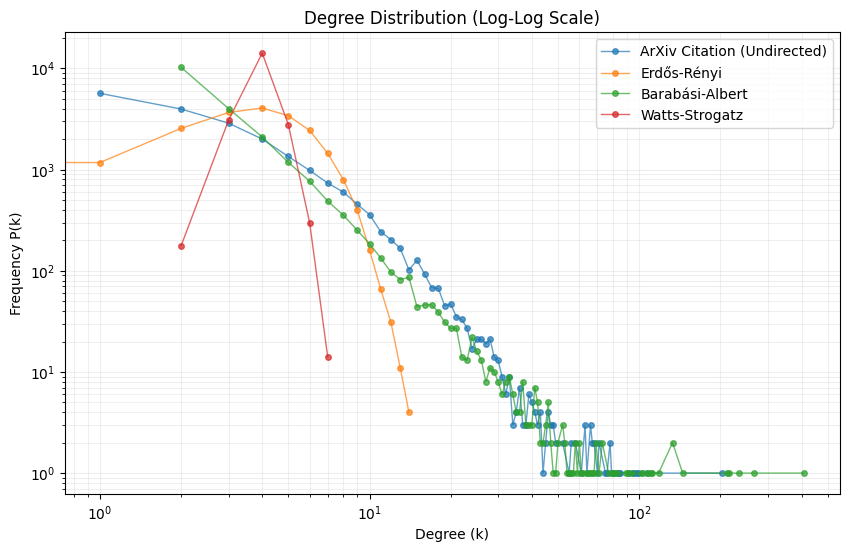

In [11]:
graphs = [G_undir, erdos, barabasi, watts]
labels = ["ArXiv Citation (Undirected)", "Erdős-Rényi", "Barabási-Albert", "Watts-Strogatz"]

network_utils.plot_degree_distribution(graphs, labels)

We see that ArXiv Citations network follows Barabasi-Albert Degree Distribution so it means that the Network is close to being scale-free.

In [12]:
df_watts = network_utils.describe_network_undirected(watts)

In [13]:
df_barabasi = network_utils.describe_network_undirected(barabasi)

In [14]:
df_erdos = network_utils.describe_network_undirected(erdos)

In [15]:
df_citations = network_utils.describe_network_undirected(G_undir)

In [17]:
df_citations

,Nodes,Edges,Average Degree,Connected Components,Average Clustering Coefficient,Largest Connected Component,Average Shortest Path
0,20515,44119,4.301146,965,0.247071,16874,10.383666


In [16]:
df_watts

,Nodes,Edges,Average Degree,Connected Components,Average Clustering Coefficient,Largest Connected Component,Average Shortest Path
0,20515,41030,4.0,1,0.37376,20515,13.548513


In [18]:
df_erdos

,Nodes,Edges,Average Degree,Connected Components,Average Clustering Coefficient,Largest Connected Component,Average Shortest Path
0,20515,44119,4.301146,294,0.000157,20215,6.962949


In [19]:
df_barabasi

,Nodes,Edges,Average Degree,Connected Components,Average Clustering Coefficient,Largest Connected Component,Average Shortest Path
0,20515,41026,3.99961,1,0.002511,20515,5.31756


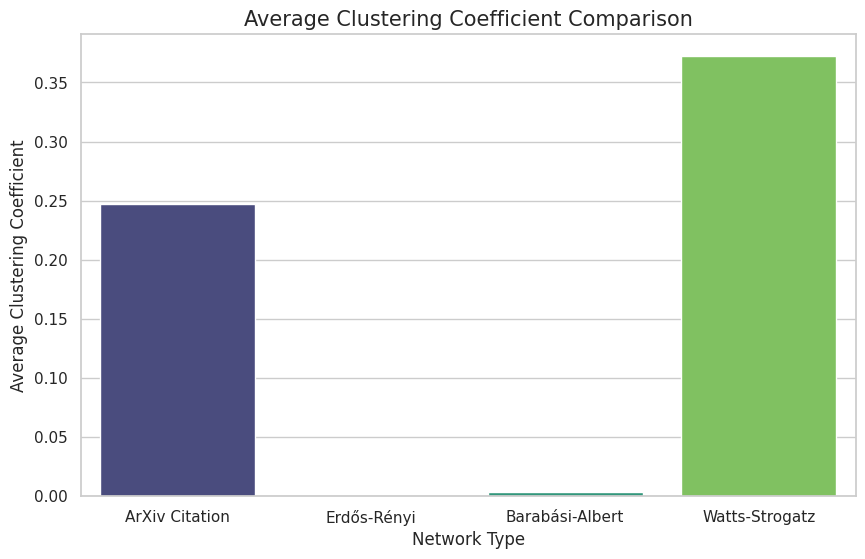

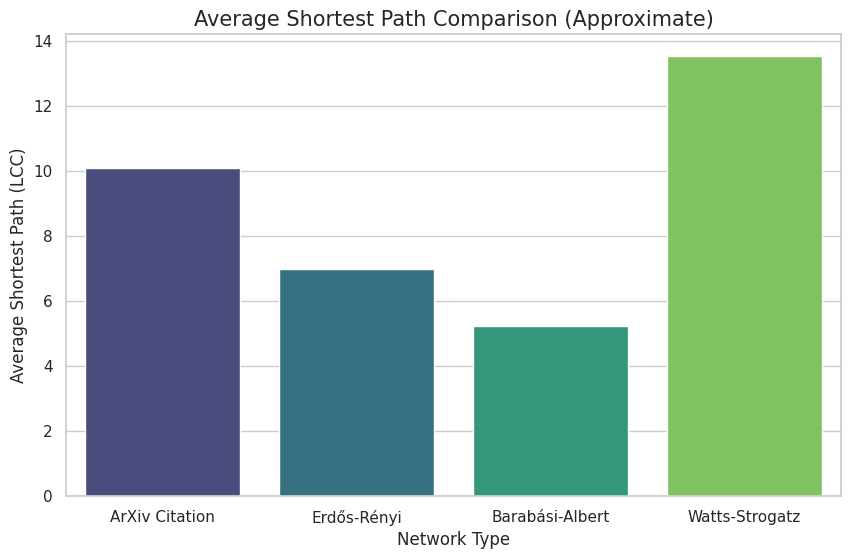

In [20]:
results = pd.concat([df_citations, df_erdos, df_barabasi, df_watts], ignore_index=True)
results['Network'] = ["ArXiv Citation", "Erdős-Rényi", "Barabási-Albert", "Watts-Strogatz"]

import seaborn as sns
import matplotlib.pyplot as plt
sns.set_theme(style="whitegrid")

# Plot 1: Average Clustering Coefficient
plt.figure(figsize=(10, 6))
sns.barplot(data=results, x='Network', y='Average Clustering Coefficient', hue='Network', palette='viridis', legend=False)
plt.title('Average Clustering Coefficient Comparison', fontsize=15)
plt.ylabel('Average Clustering Coefficient', fontsize=12)
plt.xlabel('Network Type', fontsize=12)
plt.show()

# Plot 2: Average Shortest Path
plt.figure(figsize=(10, 6))
sns.barplot(data=results, x='Network', y='Average Shortest Path', hue='Network', palette='viridis', legend=False)
plt.title('Average Shortest Path Comparison (Approximate)', fontsize=15)
plt.ylabel('Average Shortest Path (LCC)', fontsize=12)
plt.xlabel('Network Type', fontsize=12)
plt.show()

In [21]:
results

,Nodes,Edges,Average Degree,Connected Components,Average Clustering Coefficient,Largest Connected Component,Average Shortest Path,Network
0,20515,44119,4.301146,965,0.247071,16874,10.099556,ArXiv Citation
1,20515,44119,4.301146,294,0.000181,20217,6.989523,Erdős-Rényi
2,20515,41026,3.999610,1,0.003645,20515,5.243597,Barabási-Albert
3,20515,41030,4.000000,1,0.372153,20515,13.530906,Watts-Strogatz


### Centrality Measures to identify the most impactful papers

In [22]:
titleabs_df = pd.read_csv(
    "titleabs.tsv", 
    sep="\t", 
    header=None, 
    names=["paper id", "title", "abstract"]
)

titleabs_df["paper id"] = titleabs_df["paper id"].astype(int)
titleabs_df = titleabs_df.merge(labels_merged[["paper id", "arxiv category"]], on="paper id")

titleabs_indexed = titleabs_df.set_index("paper id")
titleabs_indexed.head()

,title,abstract,arxiv category
paper id,,,
630234,spreadsheets on the move an evaluation of mobi...,The power of mobile devices has increased dram...,arxiv cs hc
803423,multi view metric learning for multi view vide...,Traditional methods on video summarization are...,arxiv cs cv
1102481,big data analytics in future internet of things,Current research on Internet of Things (IoT) m...,arxiv cs dc
1532644,machine learner for automated reasoning 0 4 an...,Machine Learner for Automated Reasoning (MaLAR...,arxiv cs lg
1810480,cryptographic hardening of d sequences,This paper shows how a one-way mapping using m...,arxiv cs cr


In [23]:
pagerank = nx.pagerank(G)
pagerank_ranking = network_utils.get_top_papers_by_centrality(titleabs_indexed, pagerank, "pagerank", node_mapping)

In [24]:
degree = nx.in_degree_centrality(G)
degree_ranking = network_utils.get_top_papers_by_centrality(titleabs_indexed, degree, "degree", node_mapping)


In [25]:
betweenness = nx.betweenness_centrality(G, k=1000, seed=23)
betweenness_ranking = network_utils.get_top_papers_by_centrality(titleabs_indexed, betweenness, "betweenness", node_mapping)

Interestingly, the Information Theory category represents 75% of the most important papers computed by PageRank.
The papers mostly focus on error-correcting coding, wireless networks and interference within them and information compression.

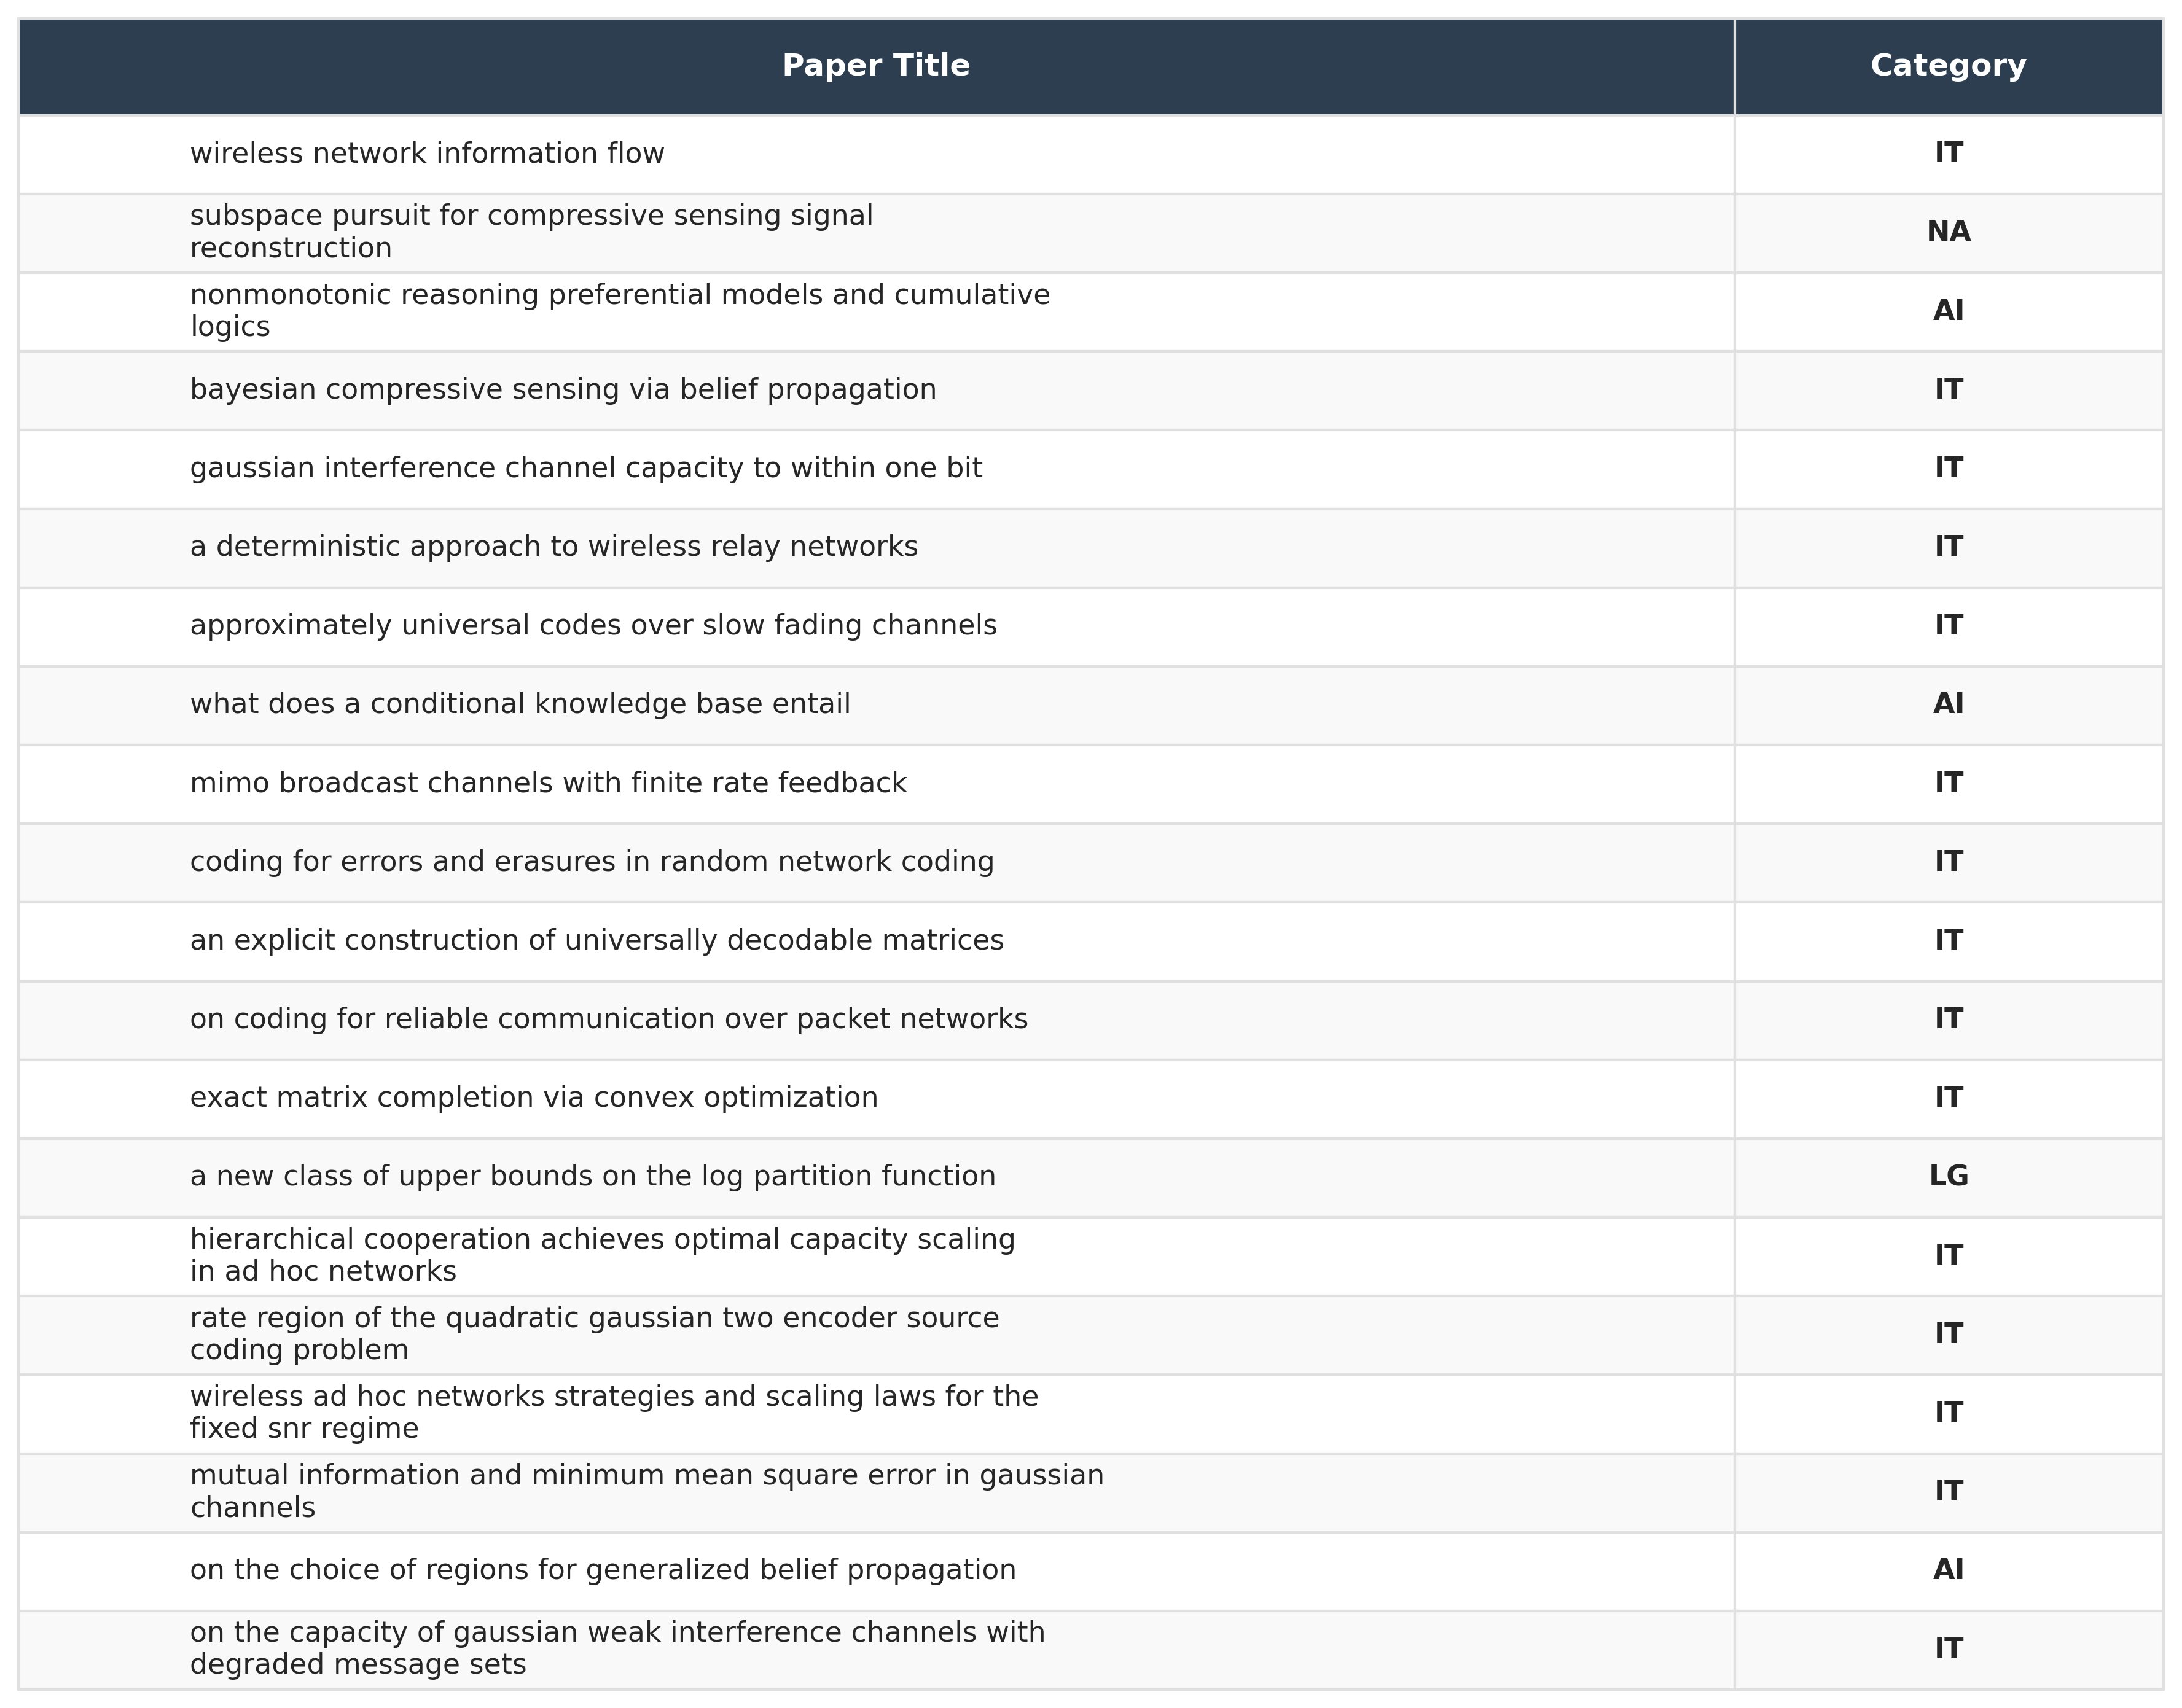

In [26]:
import matplotlib.pyplot as plt
import textwrap

# 1. Use the entire pagerank_ranking table
table_data = pagerank_ranking.copy()

# 2. Clean category name and wrap long titles
table_data["category"] = table_data["arxiv category"].str.replace("arxiv cs ", "").str.upper()
table_data["title_wrapped"] = table_data["title"].map(lambda x: "\n".join(textwrap.wrap(x, width=60)))

# Keep only Title and Category columns
table_df = table_data[["title_wrapped", "category"]].copy()
table_df.columns = ["Paper Title", "Category"]

# 3. Adjust figure height dynamically based on the number of rows
fig_height = 0.8 + 0.45 * len(table_df)
fig, ax = plt.subplots(figsize=(12, fig_height), dpi=300)
ax.axis('off')

# Table styling colors
header_color = '#2c3e50'    # Premium dark blue header
row_colors = ['#f9f9f9', '#ffffff'] # Alternating row colors
edge_color = '#e0e0e0'

tbl = ax.table(
    cellText=table_df.values,
    colLabels=table_df.columns,
    loc='center',
    cellLoc='left',
    colWidths=[0.8, 0.2]     # 80% width for titles, 20% for category
)

tbl.auto_set_font_size(False)
tbl.set_fontsize(11)

# Style cells individually
for (row, col), cell in tbl.get_celld().items():
    cell.set_edgecolor(edge_color)
    cell.set_linewidth(1)
    
    if row == 0:
        cell.set_text_props(weight='bold', color='white', fontsize=12)
        cell.set_facecolor(header_color)
        cell.set_height(0.08)
    else:
        cell.set_facecolor(row_colors[row % len(row_colors)])
        cell.set_height(0.065)
        # Center-align and bold the categories
        if col == 1:
            cell.set_text_props(weight='semibold', ha='center')

# Center-align the Category header
tbl[0, 1].set_text_props(ha='center')

plt.tight_layout()
plt.show()


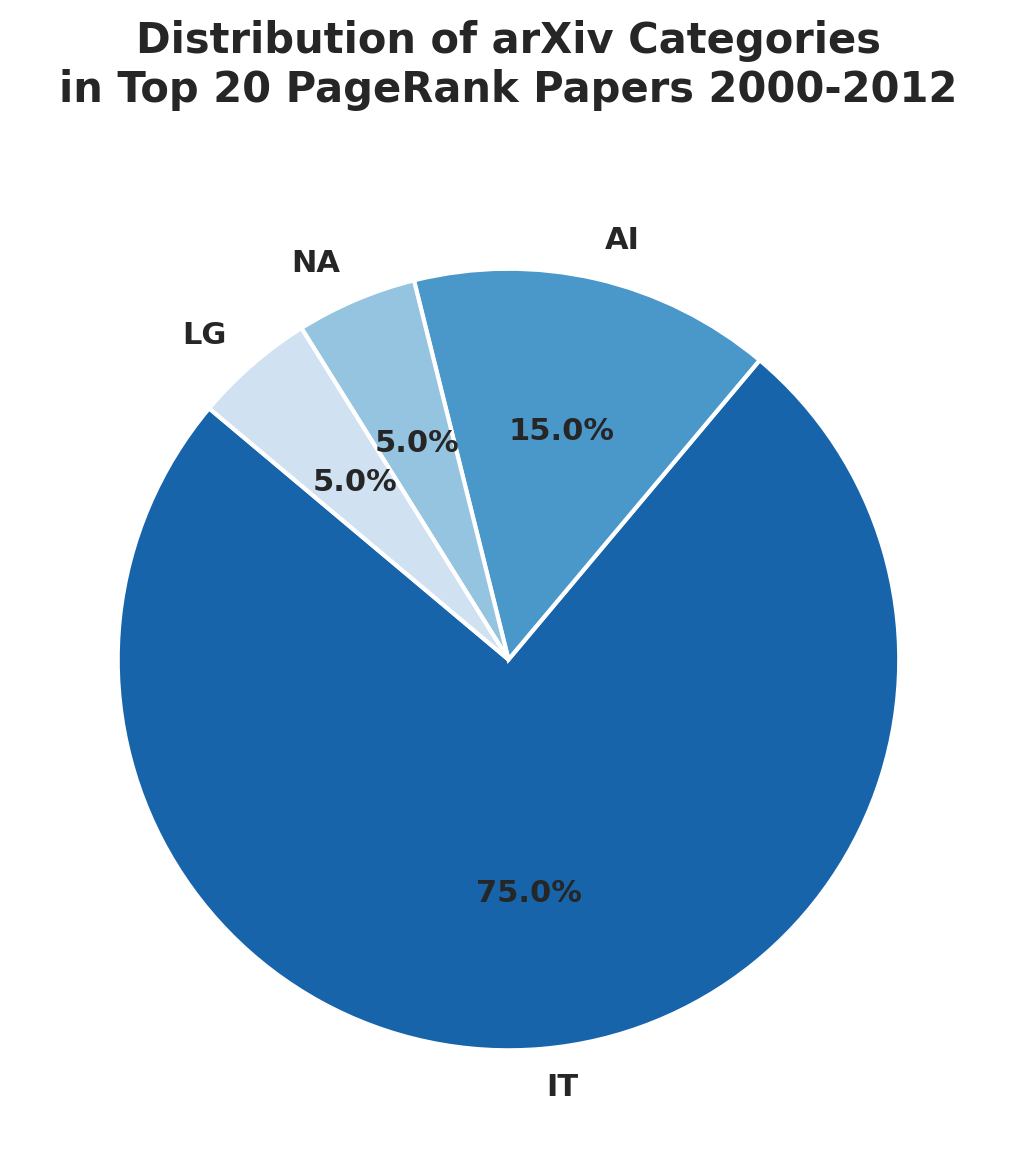

In [27]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Set a clean, modern aesthetic style
sns.set_theme(style="whitegrid")

# 1. Grab the top 20 papers from the pagerank_ranking DataFrame
top_20_papers = pagerank_ranking.head(20).copy()

# 2. Clean the category names (e.g., "arxiv cs it" -> "IT")
top_20_papers['category'] = top_20_papers['arxiv category'].str.replace('arxiv cs ', '').str.upper()

# 3. Count how many times each category appears in the top 20
category_counts = top_20_papers['category'].value_counts().reset_index()
category_counts.columns = ['category', 'count']

# 4. Generate the Pie Chart
plt.figure(figsize=(6, 6), dpi=200)

# Colors palette
colors = sns.color_palette("Blues_r", len(category_counts))

plt.pie(
    category_counts['count'],
    labels=category_counts['category'],
    autopct='%1.1f%%',
    startangle=140,
    colors=colors,
    wedgeprops={'edgecolor': 'white', 'linewidth': 1.5, 'antialiased': True},
    textprops={'fontsize': 11, 'fontweight': 'bold'}
)

plt.title("Distribution of arXiv Categories\nin Top 20 PageRank Papers 2000-2012", fontsize=15, fontweight='bold', pad=25)
plt.tight_layout()
plt.show()


In the Degree centrality it's even more prominent. The reasons are similar but something else might be also true. That the community of information theory, wireless communication, coding really stood out as the most writing and citing community in the 2000s. It was probably really dense and shows that many people at the time were focused on solving WiFi and wireless communication. It is also the time when 3G and LTE started appearing.

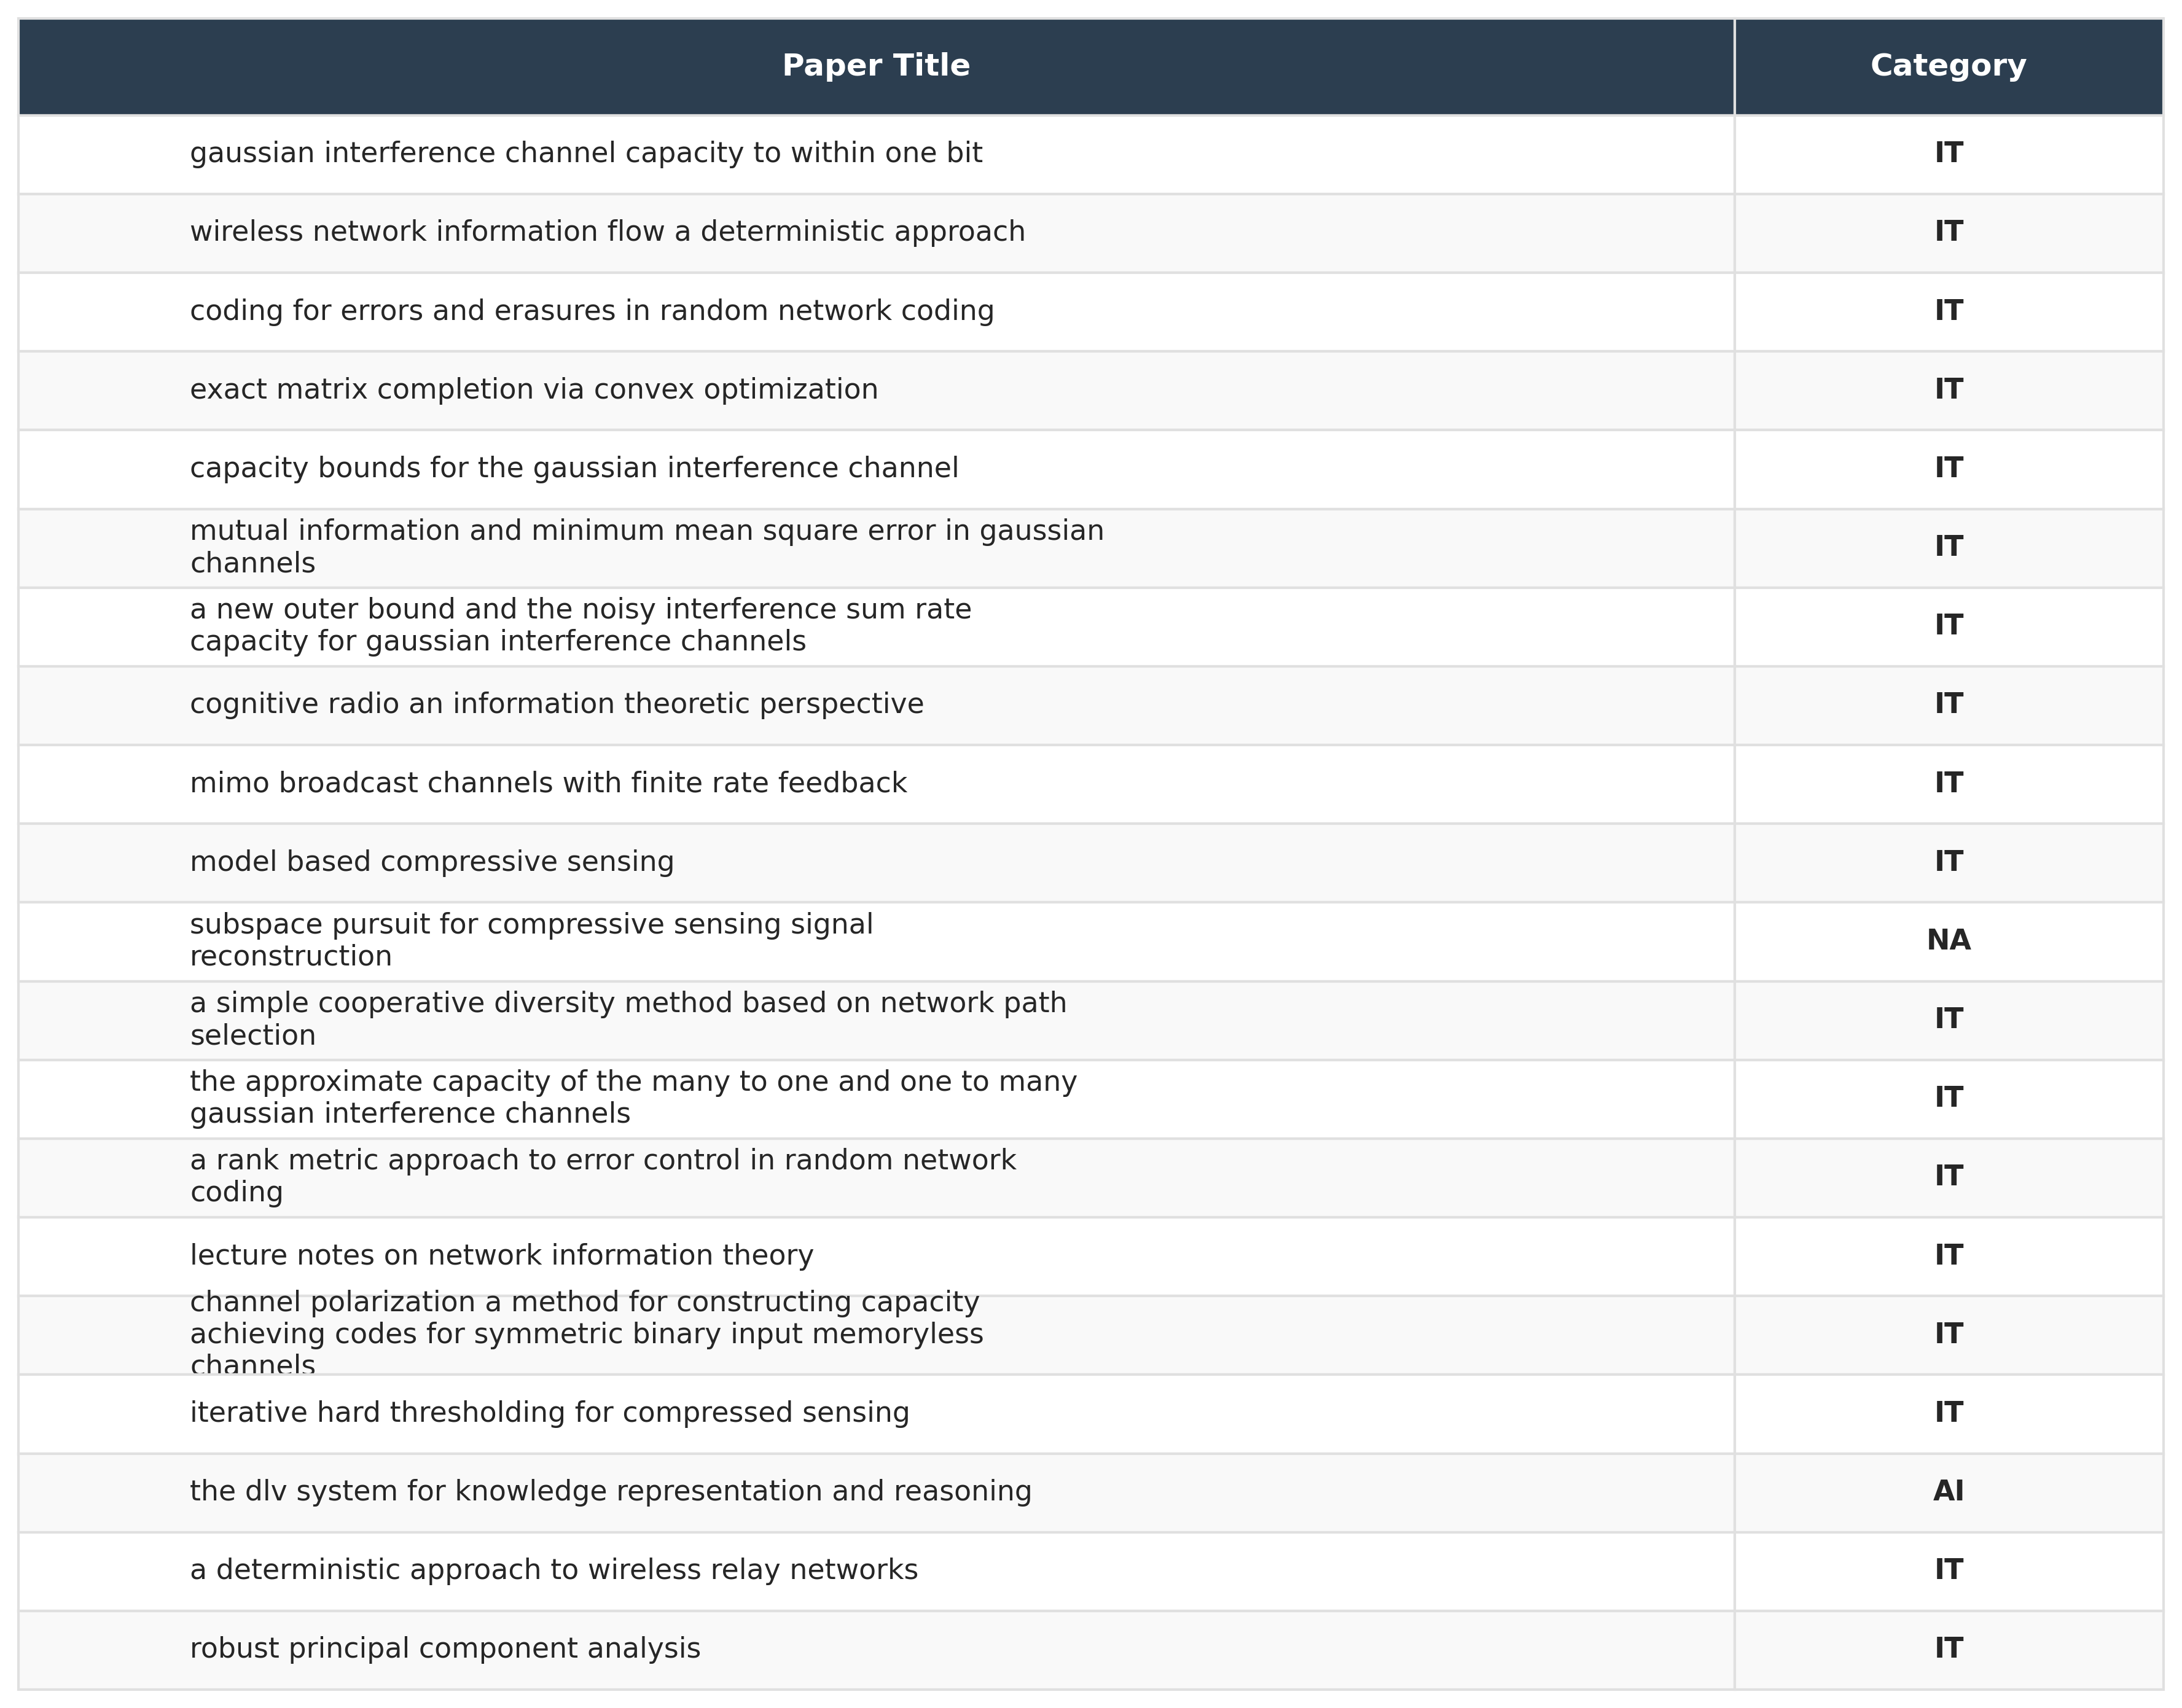

In [28]:
import matplotlib.pyplot as plt
import textwrap

# 1. Use the entire degree_ranking table
table_data = degree_ranking.copy()

# 2. Clean category name and wrap long titles
table_data["category"] = table_data["arxiv category"].str.replace("arxiv cs ", "").str.upper()
table_data["title_wrapped"] = table_data["title"].map(lambda x: "\n".join(textwrap.wrap(x, width=60)))

# Keep only Title and Category columns
table_df = table_data[["title_wrapped", "category"]].copy()
table_df.columns = ["Paper Title", "Category"]

# 3. Adjust figure height dynamically based on the number of rows
fig_height = 0.8 + 0.45 * len(table_df)
fig, ax = plt.subplots(figsize=(12, fig_height), dpi=300)
ax.axis('off')

# Table styling colors
header_color = '#2c3e50'    # Premium dark blue header
row_colors = ['#f9f9f9', '#ffffff'] # Alternating row colors
edge_color = '#e0e0e0'

tbl = ax.table(
    cellText=table_df.values,
    colLabels=table_df.columns,
    loc='center',
    cellLoc='left',
    colWidths=[0.8, 0.2]     # 80% width for titles, 20% for category
)

tbl.auto_set_font_size(False)
tbl.set_fontsize(11)

# Style cells individually
for (row, col), cell in tbl.get_celld().items():
    cell.set_edgecolor(edge_color)
    cell.set_linewidth(1)
    
    if row == 0:
        cell.set_text_props(weight='bold', color='white', fontsize=12)
        cell.set_facecolor(header_color)
        cell.set_height(0.08)
    else:
        cell.set_facecolor(row_colors[row % len(row_colors)])
        cell.set_height(0.065)
        # Center-align and bold the categories
        if col == 1:
            cell.set_text_props(weight='semibold', ha='center')

# Center-align the Category header
tbl[0, 1].set_text_props(ha='center')

plt.tight_layout()
plt.show()


Betweenness centrality however shows different nodes. It mostly focuses on bridges that are nodes connecting multiple Computer Science areas and are generally most important for Computer Science in general rather than being really important only for a subgroup of categories.

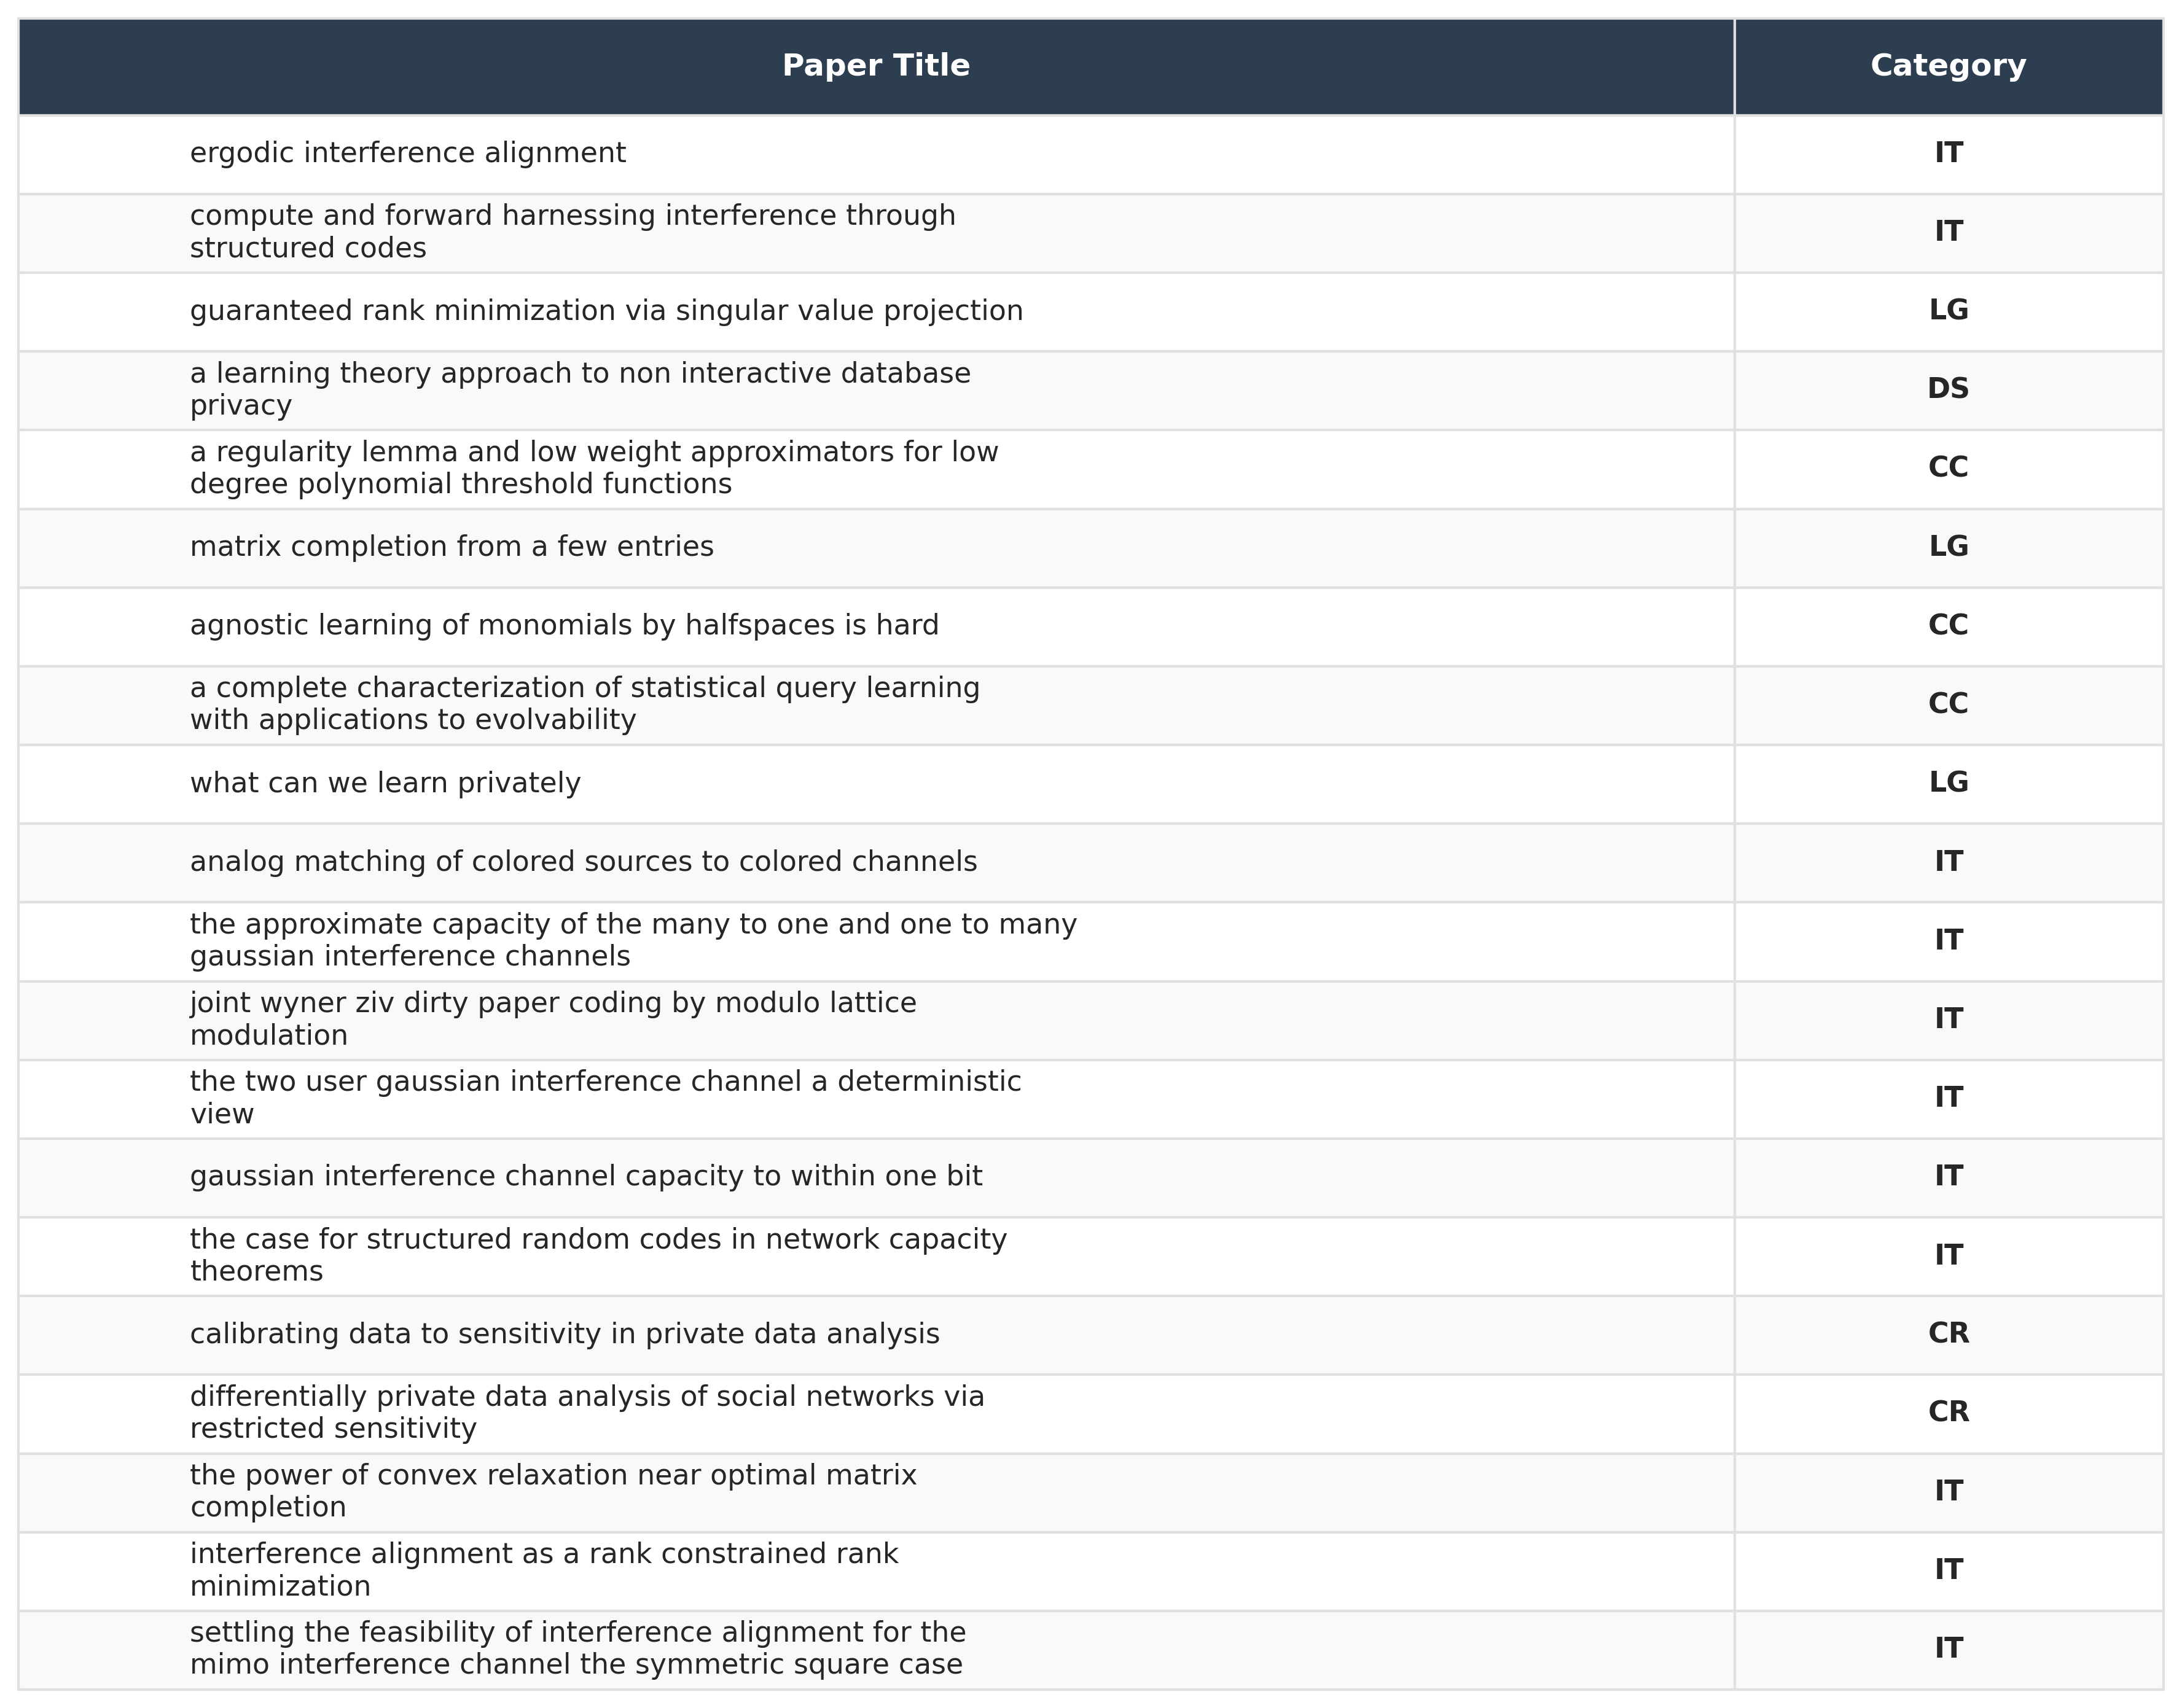

In [29]:
import matplotlib.pyplot as plt
import textwrap

# 1. Use the entire betweenness_ranking table
table_data = betweenness_ranking.copy()

# 2. Clean category name and wrap long titles
table_data["category"] = table_data["arxiv category"].str.replace("arxiv cs ", "").str.upper()
table_data["title_wrapped"] = table_data["title"].map(lambda x: "\n".join(textwrap.wrap(x, width=60)))

# Keep only Title and Category columns
table_df = table_data[["title_wrapped", "category"]].copy()
table_df.columns = ["Paper Title", "Category"]

# 3. Adjust figure height dynamically based on the number of rows
fig_height = 0.8 + 0.45 * len(table_df)
fig, ax = plt.subplots(figsize=(12, fig_height), dpi=300)
ax.axis('off')

# Table styling colors
header_color = '#2c3e50'    # Premium dark blue header
row_colors = ['#f9f9f9', '#ffffff'] # Alternating row colors
edge_color = '#e0e0e0'

tbl = ax.table(
    cellText=table_df.values,
    colLabels=table_df.columns,
    loc='center',
    cellLoc='left',
    colWidths=[0.8, 0.2]     # 80% width for titles, 20% for category
)

tbl.auto_set_font_size(False)
tbl.set_fontsize(11)

# Style cells individually
for (row, col), cell in tbl.get_celld().items():
    cell.set_edgecolor(edge_color)
    cell.set_linewidth(1)
    
    if row == 0:
        cell.set_text_props(weight='bold', color='white', fontsize=12)
        cell.set_facecolor(header_color)
        cell.set_height(0.08)
    else:
        cell.set_facecolor(row_colors[row % len(row_colors)])
        cell.set_height(0.065)
        # Center-align and bold the categories
        if col == 1:
            cell.set_text_props(weight='semibold', ha='center')

# Center-align the Category header
tbl[0, 1].set_text_props(ha='center')

plt.tight_layout()
plt.show()


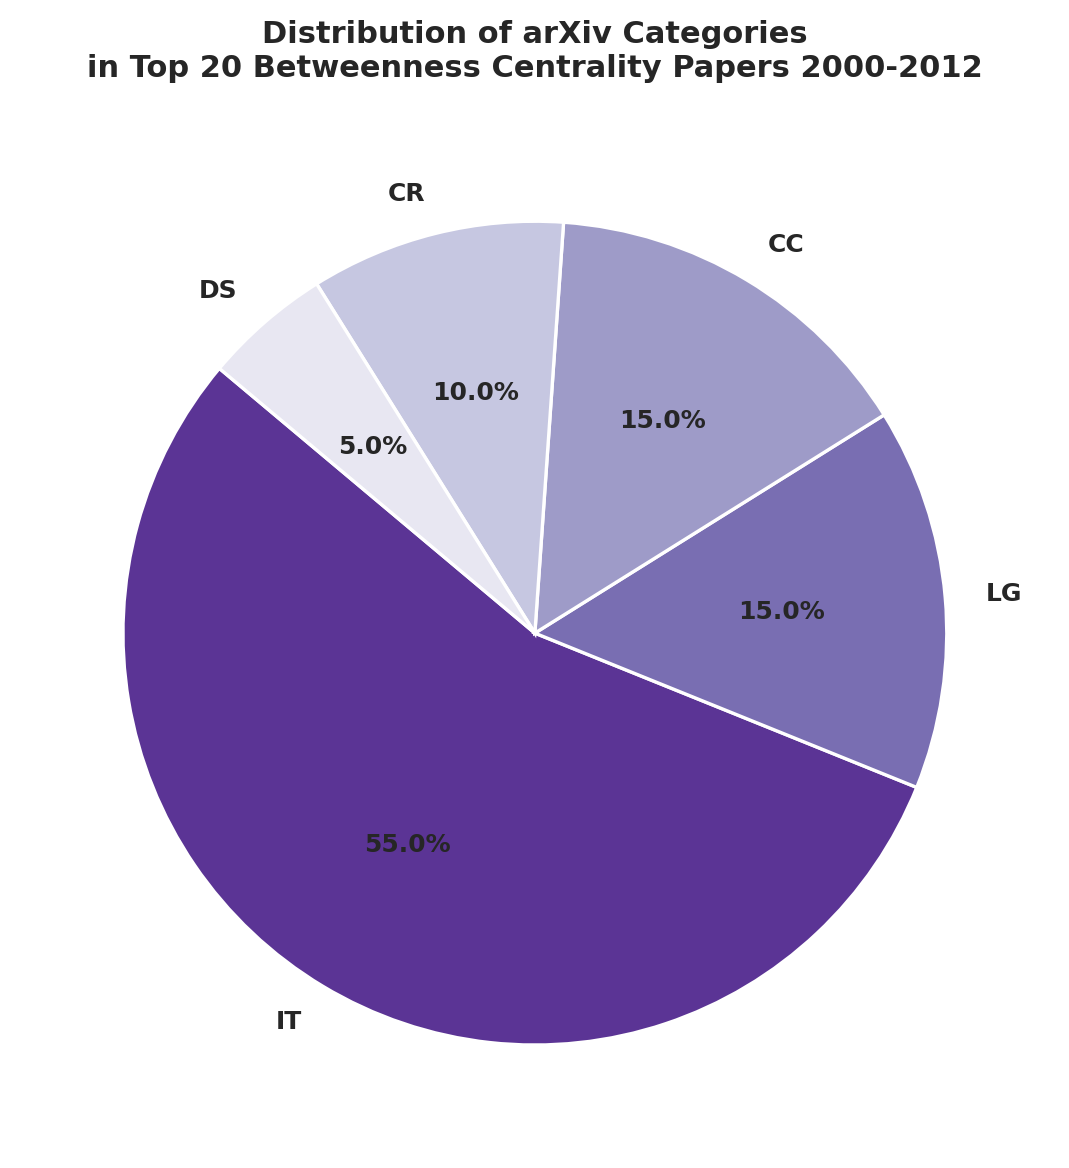

In [30]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Set a clean, modern aesthetic style
sns.set_theme(style="whitegrid")

# 1. Grab the top 20 papers from the betweenness_ranking DataFrame
top_20_papers_bt = betweenness_ranking.head(20).copy()

# 2. Clean the category names
top_20_papers_bt['category'] = top_20_papers_bt['arxiv category'].str.replace('arxiv cs ', '').str.upper()

# 3. Count how many times each category appears in the top 20
category_counts_bt = top_20_papers_bt['category'].value_counts().reset_index()
category_counts_bt.columns = ['category', 'count']

# 4. Generate the Pie Chart
plt.figure(figsize=(6, 6), dpi=200)

# Using a distinct color palette (Purples_r) to differentiate from the PageRank chart
colors = sns.color_palette("Purples_r", len(category_counts_bt))

plt.pie(
    category_counts_bt['count'],
    labels=category_counts_bt['category'],
    autopct='%1.1f%%',
    startangle=140,
    colors=colors,
    wedgeprops={'edgecolor': 'white', 'linewidth': 1.2, 'antialiased': True},
    textprops={'fontsize': 9, 'fontweight': 'bold'}
)

plt.title("Distribution of arXiv Categories\nin Top 20 Betweenness Centrality Papers 2000-2012", fontsize=11, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()


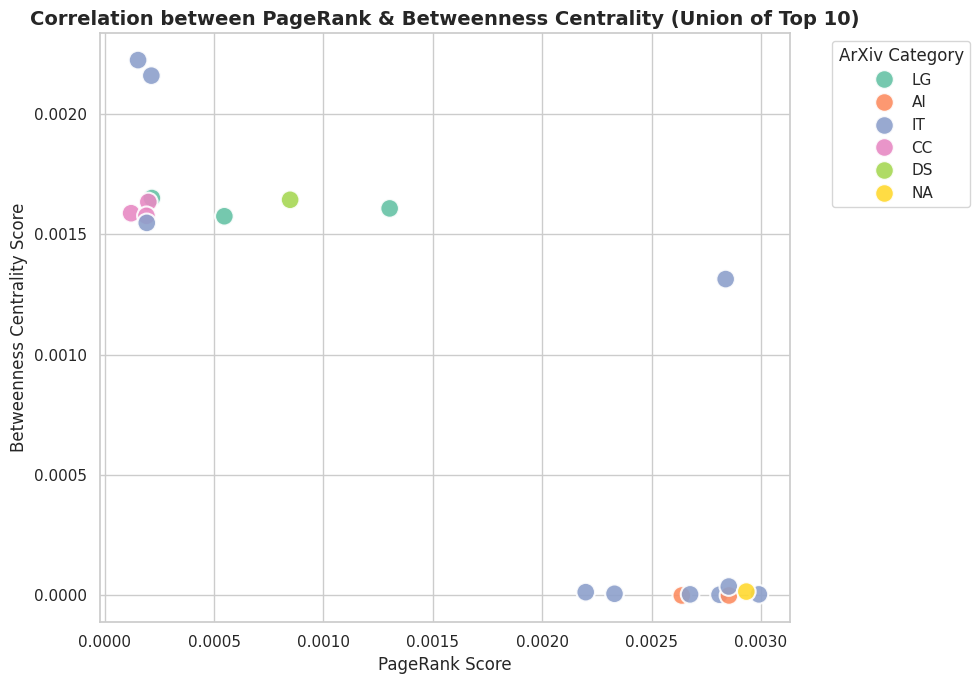

In [31]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Grab the top 10 papers from each ranking DataFrame
top_pr = pagerank_ranking.head(10)
top_bt = betweenness_ranking.head(10)

# 2. Get the union of the paper IDs (which are the index labels)
top_union_ids = list(set(top_pr.index.tolist() + top_bt.index.tolist()))

# 3. Combine the metadata (titles and categories) from both dataframes
combined_metadata = pd.concat([
    pagerank_ranking[['title', 'arxiv category']], 
    betweenness_ranking[['title', 'arxiv category']]
])
# Remove duplicate paper index entries
union_metadata = combined_metadata.loc[~combined_metadata.index.duplicated(keep='first')]

# Filter to keep only the union of top 10 papers
plot_df = union_metadata.loc[top_union_ids].copy()

# 4. Map the node idx and retrieve scores from pagerank & betweenness dicts to prevent NaN values
paper_to_node = dict(zip(node_mapping['paper id'], node_mapping['node idx']))
plot_df['node idx'] = plot_df.index.map(paper_to_node)

plot_df['pagerank'] = plot_df['node idx'].map(pagerank)
plot_df['betweenness'] = plot_df['node idx'].map(betweenness)

# 5. Clean category names for the legend
plot_df["category"] = plot_df["arxiv category"].str.replace("arxiv cs ", "").str.upper()

# 6. Create the correlation plot
plt.figure(figsize=(10, 7))
sns.set_theme(style="whitegrid")

# Draw the scatter plot
sns.scatterplot(
    data=plot_df,
    x='pagerank',
    y='betweenness',
    hue='category',
    palette='Set2',    # Harmonious colors for categories
    s=180,             # Size of the points
    alpha=0.9,
    edgecolor='w',
    linewidth=1.5
)

plt.title("Correlation between PageRank & Betweenness Centrality (Union of Top 10)", fontsize=14, fontweight='bold')
plt.xlabel("PageRank Score", fontsize=12)
plt.ylabel("Betweenness Centrality Score", fontsize=12)
plt.legend(title="ArXiv Category", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


### Community Detection

Now we will explore if it is possible to group the nodes into communities (categories) based on network structure alone, so that
the detected communities overlap with ArXiV Computer Science paper categories.
For that we will use well-known algorithms for Community Detection.

In [32]:
import importlib
importlib.reload(network_utils)
lcc_nodes = max(nx.weakly_connected_components(G), key=len)
G_lcc = G.subgraph(lcc_nodes)

#### Results

As we see the Louvain and Leiden algorithms achieved the best modularity as well as found significantly bigger communities which in this case is more interpretable. Most of these communities have dominant ArXiV category which means that those categories cluster together and can be easily distiguished by just looking at the citations between them. Other algorithms like Walktrap and Label Propagation also achieved high modularity, although they found many smaller communities  with pretty high one category domination, which might mean that there are smaller communities (within some categories) perhaps papers published by the same university. Either way communities emerge clearly in the Computer Science research.

In [33]:
from cdlib import algorithms
# --- Louvain ---
print("Running Louvain...")
louvain_communities = nx.community.louvain_communities(G_lcc)
louvain_mod, louvain_size, louvain_accuracy, louvain_df = network_utils.evaluate_communities(
    G_lcc, louvain_communities, labels_merged[["node idx", "arxiv category"]]
)
# --- Walktrap ---
print("Running Walktrap...")
walktrap_coms = algorithms.walktrap(G_lcc.to_undirected())
walktrap_communities = [set(c) for c in walktrap_coms.communities]
walktrap_mod, walktrap_size, walktrap_accuracy, walktrap_df = network_utils.evaluate_communities(
    G_lcc, walktrap_communities, labels_merged[["node idx", "arxiv category"]]
)
# --- Label Propagation ---
print("Running Label Propagation...")
label_prop_communities = list(nx.community.fast_label_propagation_communities(G_lcc))
label_prop_mod, label_prop_size, label_prop_accuracy, label_prop_df = network_utils.evaluate_communities(
    G_lcc, label_prop_communities, labels_merged[["node idx", "arxiv category"]]
)
# --- Leiden ---
print("Running Leiden...")
leiden_coms = algorithms.leiden(G_lcc)
leiden_communities = [set(c) for c in leiden_coms.communities]
leiden_mod, leiden_size, leiden_accuracy, leiden_df = network_utils.evaluate_communities(
    G_lcc, leiden_communities, labels_merged[["node idx", "arxiv category"]]
)


Note: to be able to use all crisp methods, you need to install some additional packages:  {'wurlitzer', 'infomap', 'graph_tool', 'bayanpy'}
Note: to be able to use all crisp methods, you need to install some additional packages:  {'ASLPAw', 'pyclustering'}
Note: to be able to use all crisp methods, you need to install some additional packages:  {'wurlitzer', 'infomap'}
Running Louvain...
Running Walktrap...
Running Label Propagation...
Running Leiden...


In [34]:
alg_names = ['Louvain', 'Walktrap', 'Label Prop', 'Leiden']
modularities = [louvain_mod, walktrap_mod, label_prop_mod, leiden_mod]
avg_sizes = [louvain_size, walktrap_size, label_prop_size, leiden_size]
avg_purity = [
    louvain_df['percentage'].mean(),
    walktrap_df['percentage'].mean(),
    label_prop_df['percentage'].mean(),
    leiden_df['percentage'].mean()
]
std_purity = [
    louvain_df['percentage'].std(),
    walktrap_df['percentage'].std(),
    label_prop_df['percentage'].std(),
    leiden_df['percentage'].std()
]

accuracies = [
    louvain_accuracy,
    walktrap_accuracy,
    label_prop_accuracy,
    leiden_accuracy
]


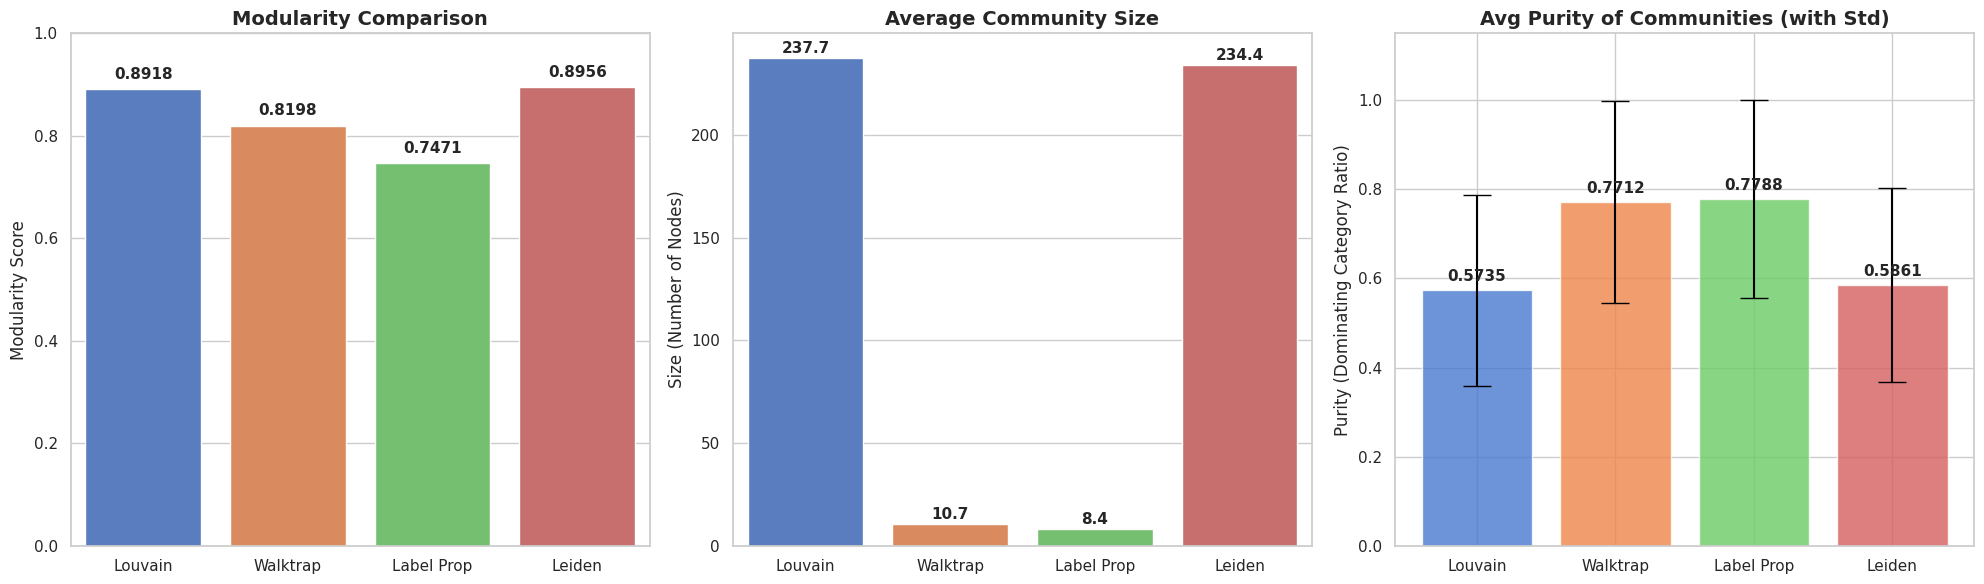

In [35]:
sns.set_theme(style="whitegrid")
colors = sns.color_palette("muted", 4)
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
# Plot 1: Modularity Comparison
sns.barplot(x=alg_names, y=modularities, ax=axes[0], palette=colors, hue=alg_names, legend=False)
axes[0].set_title("Modularity Comparison", fontsize=14, fontweight='bold')
axes[0].set_ylabel("Modularity Score", fontsize=12)
axes[0].set_ylim(0, 1.0)
for i, v in enumerate(modularities):
    axes[0].text(i, v + 0.02, f"{v:.4f}", ha='center', fontweight='bold', fontsize=11)

# Plot 2: Average Community Size
sns.barplot(x=alg_names, y=avg_sizes, ax=axes[1], palette=colors, hue=alg_names, legend=False)
axes[1].set_title("Average Community Size", fontsize=14, fontweight='bold')
axes[1].set_ylabel("Size (Number of Nodes)", fontsize=12)
# Scale text placement dynamically based on max value
max_size = max(avg_sizes)
for i, v in enumerate(avg_sizes):
    axes[1].text(i, v + (max_size * 0.01), f"{v:.1f}", ha='center', fontweight='bold', fontsize=11)


# Plot 3: Average Purity of Communities with Standard Deviation
axes[2].bar(alg_names, avg_purity, yerr=std_purity, align='center', alpha=0.8, 
           ecolor='black', capsize=10, color=colors)
axes[2].set_title("Avg Purity of Communities (with Std)", fontsize=14, fontweight='bold')
axes[2].set_ylabel("Purity (Dominating Category Ratio)", fontsize=12)
axes[2].set_ylim(0, 1.15)
for i, v in enumerate(avg_purity):
    axes[2].text(i, v + 0.02, f"{v:.4f}", ha='center', fontweight='bold', fontsize=11)
plt.tight_layout()
plt.show()

We will try to automatically categorize papers by majority voting, that is we will categorize a paper to a category, to which most papers in its community belong to.

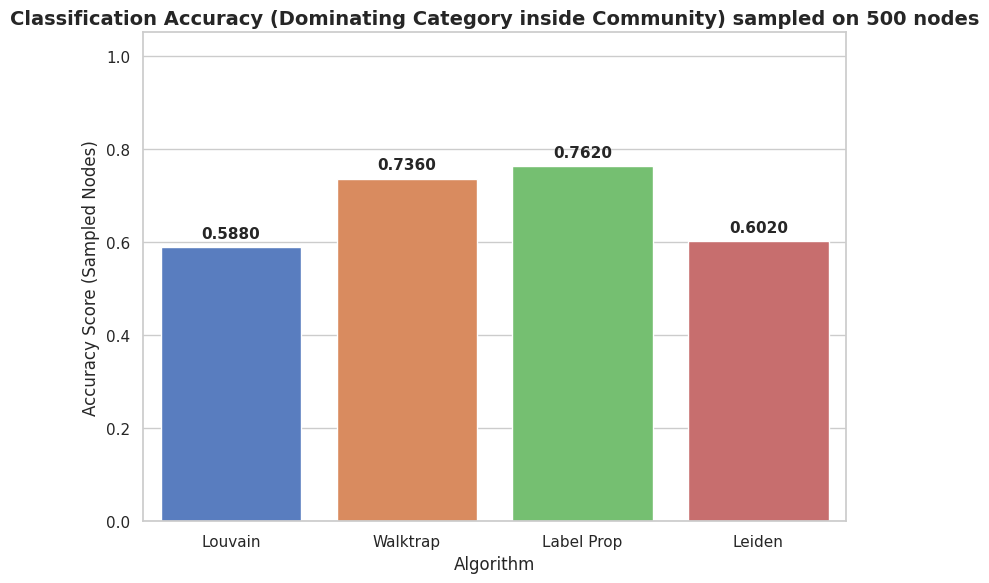

In [36]:
plt.figure(figsize=(8, 6))
sns.barplot(x=alg_names, y=accuracies, palette=colors, hue=alg_names, legend=False)
plt.title("Classification Accuracy (Dominating Category inside Community) sampled on 500 nodes", fontsize=14, fontweight='bold')
plt.ylabel("Accuracy Score (Sampled Nodes)", fontsize=12)
plt.xlabel("Algorithm", fontsize=12)
plt.ylim(0, 1.05)
for i, v in enumerate(accuracies):
    plt.text(i, v + 0.02, f"{v:.4f}", ha='center', fontweight='bold', fontsize=11)
plt.tight_layout()
plt.show()